
# 01 — การเตรียม SRTM DEM สำหรับการวิเคราะห์ Radar–Terrain  
## จาก SRTM ~90 m สู่ 1-km UTM Analysis Grid

**Google Colab teaching notebook | Geography · Geoinformatics · Environmental Science · Radar Meteorology**

Notebook นี้ต่อจาก **Notebook 00 — Setup and Download SRTM DEM** โดยใช้ source DEM ที่ดาวน์โหลดจาก Zenodo และผ่านการตรวจ file integrity แล้ว

**Zenodo DOI:** `10.5281/zenodo.22687421`

เป้าหมายของบทนี้ไม่ใช่เพียง “ลด resolution ของ DEM” แต่ให้นิสิตเข้าใจว่าเหตุใดการวิเคราะห์ลำบีมเรดาร์กับภูมิประเทศต้องให้ความสำคัญกับ


$$
\boxed{
\text{Georeferencing}
\rightarrow
\text{CRS}
\rightarrow
\text{Metric analysis domain}
\rightarrow
\text{Resampling}
\rightarrow
\text{Radar-ready DEM}
}
$$


ผลลัพธ์หลักคือ GeoTIFF ขนาดเซลล์ **1,000 × 1,000 m** ใน **WGS 84 / UTM Zone 47N (EPSG:32647)** สำหรับใช้ในบทเรียน radar geometry และ beam-blockage ต่อไป


### รูปแบบสมการที่ใช้ใน Google Colab

Notebook ชุดนี้ใช้ MathJax/LaTeX แบบที่ Google Colab แสดงผลได้เสถียร:

- สมการในบรรทัดใช้ `$ ... $`
- สมการแยกบรรทัดใช้ `$$ ... $$`

ตัวอย่าง

$$
z=f(x,y)
$$

และ

$$
r_{\max}
=
480\times500
=
240{,}000\ \mathrm{m}
=
240\ \mathrm{km}
$$

รูปแบบนี้จะใช้เหมือนกันใน Notebook ต่อ ๆ ไปทั้งหมด


## 1. คำถามนำของบทเรียน

ก่อนรันโค้ด ให้ลองตอบคำถามต่อไปนี้

1. SRTM มี nominal resolution ประมาณ 90 m อยู่แล้ว เหตุใดจึงไม่ใช้ทั้ง 6 tiles โดยตรงกับการคำนวณ radar beam blockage?
2. เหตุใด `0.008333°` หรือค่าในหน่วย degree จึงไม่ควรถูกเรียกว่า “1 km” อย่างเคร่งครัด?
3. เหตุใดงานที่เกี่ยวข้องกับระยะทาง **240 km** จึงเหมาะกับ projected CRS ที่มีหน่วยเป็น metre?
4. หากลด DEM จาก ~90 m เป็น 1 km การใช้ `average` กับ `maximum` จะให้ representation ของแนวสันเขาเหมือนกันหรือไม่?
5. เหตุใดค่าระดับความสูงจาก **1-km MAX DEM** ไม่ควรถูกนำไปใช้เป็น ground elevation ของตัวเรดาร์โดยตรง?

คำถามเหล่านี้คือแก่นของ Notebook นี้



## 2. Learning Outcomes

เมื่อจบ Notebook นี้ นิสิตควรสามารถ:

- อธิบายความหมายของ **pixel size, raster extent, NoData, affine transform และ CRS**
- อ่านและตีความค่าทั้ง 6 ค่าใน TIFF World File (`.tfw`)
- อธิบายความต่างระหว่าง **pixel centre** และ **pixel corner**
- ตรวจสอบว่า source DEM มีความละเอียดประมาณ **3 arc-seconds**
- แปลงตำแหน่งเรดาร์จาก geographic coordinates ไปเป็น **UTM Zone 47N**
- สร้าง common analysis domain จากรัศมีเรดาร์ **240 km**
- อธิบายเหตุผลของการเลือก **maximum-elevation resampling**
- reproject และ downsample DEM โดยไม่สร้าง native-resolution mosaic ขนาดใหญ่อยู่ใน RAM
- ประเมินความสมบูรณ์ของ 1-km DEM ด้วย spatial QC
- แยกความแตกต่างระหว่าง **terrain representation สำหรับ blockage** กับ **site ground elevation**



# Part A — จาก Raster GIS สู่ Radar Analysis Grid

## 3. DEM เป็น Raster อย่างไร?

DEM สามารถเขียนอย่างง่ายเป็น


$$
z = f(x,y)
$$


แต่ในคอมพิวเตอร์ข้อมูลถูกเก็บในรูปเมทริกซ์


$$
Z_{ij}
$$


โดย $i$ คือ row และ $j$ คือ column

สิ่งสำคัญคือ array index เพียงอย่างเดียวไม่ได้บอกว่า pixel นั้นอยู่ที่ใดบนโลก เราจึงต้องมี **georeferencing** เพื่อเชื่อม


$$
(row,\ column)
\longleftrightarrow
(x,\ y)
$$


และต้องมี **Coordinate Reference System (CRS)** เพื่อบอกว่าค่า $x,y$ มีความหมายทางภูมิศาสตร์อย่างไร


## 4. TIFF World File และ Affine Transformation

World file (`.tfw`) ใช้บอกความสัมพันธ์ระหว่าง **ตำแหน่ง pixel ใน raster** กับ **พิกัดบนพื้นโลก**  
โดยทั่วไปประกอบด้วยค่าตัวเลข 6 ค่า เรียงตามลำดับ

$$
A,\;D,\;B,\;E,\;C,\;F
$$

สำหรับ pixel ที่มี column = $c$ และ row = $r$ พิกัดของ **จุดศูนย์กลาง pixel** สามารถคำนวณได้จาก

$$
x_{\mathrm{center}}
=
A c + B r + C
$$

$$
y_{\mathrm{center}}
=
D c + E r + F
$$

โดยที่

- $A$ = ขนาด pixel ตามแกน $x$
- $E$ = ขนาด pixel ตามแกน $y$ ซึ่งมักเป็นค่าลบสำหรับ north-up raster
- $B$ และ $D$ = rotation terms
- $C$ และ $F$ = พิกัดของ **จุดศูนย์กลางของ pixel บนซ้าย**
- $c$ = column
- $r$ = row

### Pixel centre กับ pixel corner

World file อ้างอิง $C,F$ ที่ **จุดศูนย์กลางของ pixel บนซ้าย**  
แต่ GDAL/Rasterio `Affine` transform อ้างอิงที่ **มุมบนซ้ายของ pixel บนซ้าย**

ดังนั้นต้องเลื่อนกลับครึ่ง pixel หรือทำ **half-pixel correction**

$$
x_{\mathrm{corner}}
=
C
-
\frac{A}{2}
-
\frac{B}{2}
$$

และ

$$
y_{\mathrm{corner}}
=
F
-
\frac{D}{2}
-
\frac{E}{2}
$$

สำหรับ raster แบบ north-up ซึ่งไม่มีการหมุน โดยทั่วไป $B=D=0$ จึงลดรูปเป็น

$$
x_{\mathrm{corner}}
=
C-\frac{A}{2}
$$

$$
y_{\mathrm{corner}}
=
F-\frac{E}{2}
$$

> **ประเด็นสำคัญทาง GIS:** หากตีความ pixel centre และ pixel corner สลับกัน raster อาจเลื่อนเชิงพื้นที่ประมาณครึ่ง pixel ซึ่งอาจส่งผลต่อการ sample ระดับภูมิประเทศตามตำแหน่ง radar gate และการวิเคราะห์ beam blockage ในขั้นต่อไป


## 5. ทำไมต้องเปลี่ยนจาก EPSG:4326 ไป UTM?

Source DEM ของเรามี CRS เป็น **EPSG:4326 (WGS 84)** และ pixel size ประมาณ


$$
0.000833333^\circ
=
3''
$$


แต่ degree เป็น **angular unit** ไม่ใช่ distance unit

ระยะทางของ longitude $1^\circ$ ยังเปลี่ยนตาม latitude โดยประมาณตาม $\cos\phi$ ดังนั้น pixel ที่มีขนาดเท่ากันใน degree ไม่ได้มีขนาดเท่ากันใน metre ทุกพื้นที่

สำหรับการวิเคราะห์ radar ที่นิยาม


$$
r_{\max}
=
480\ \text{bins}
\times
500\ \text{m}
=
240\,000\ \text{m}
=
240\ \text{km}
$$


เราจึงสร้าง analysis grid ใน **WGS 84 / UTM Zone 47N (EPSG:32647)** เพื่อให้


$$
\Delta x = \Delta y = 1000\ \text{m}
$$


จริงในหน่วยของ projected grid



## 6. ทำไมใช้ 1-km DEM?

Source SRTM ~90 m มีรายละเอียดสูง แต่การคำนวณ beam blockage ต้อง sample terrain จำนวนมากตาม azimuth × range × elevation angle และอาจทำหลายสถานี

การใช้ 1-km regional DEM ในบทเรียนนี้จึงเป็นการประนีประนอมระหว่าง


$$
\text{Terrain detail}
\quad\leftrightarrow\quad
\text{Computational efficiency}
$$


อย่างไรก็ตาม 1 km ไม่ได้หมายความว่า “ดีที่สุดเสมอ”  
ผลของ DEM resolution จะถูกศึกษาโดยเฉพาะในบท **DEM Resolution and Resampling Sensitivity**

> **Research caution:** การลด resolution เป็นส่วนหนึ่งของแบบจำลองเชิงพื้นที่ และสามารถส่งผลต่อผลลัพธ์ beam blockage ได้



## 7. ทำไมใช้ Maximum-Elevation Resampling?

เมื่อ source DEM หลาย cell ถูกรวมเป็น cell ขนาด 1 km เราต้องกำหนดว่าจะเป็นตัวแทนของภูมิประเทศอย่างไร

### Average


$$
z_{\mathrm{avg}}
=
\frac{1}{n}\sum_{i=1}^{n} z_i
$$


เหมาะกับการแสดง “ระดับเฉลี่ย” แต่สามารถทำให้ ridge crest ต่ำลง

### Maximum


$$
z_{\max}
=
\max(z_1,z_2,\dots,z_n)
$$


รักษาจุดสูงภายใน cell ได้ดีกว่า จึงเหมาะกับการ **screening การบดบังลำบีม** แบบ conservative

อย่างไรก็ตาม MAX อาจทำให้ภูมิประเทศใน cell ขนาด 1 km สูงกว่าระดับ ณ ตำแหน่งเฉพาะจุด จึงมีหลักสำคัญว่า


$$
\boxed{
\text{1-km MAX DEM}
\neq
\text{radar-site ground elevation}
}
$$


ในบทนี้จึง sample ระดับพื้นที่สถานีจาก **native ~90-m DEM แยกต่างหาก**


In [1]:

# ============================================================
# STEP 1 — Install only packages that may be missing
# ============================================================
# ไม่ upgrade NumPy / Pandas / Matplotlib ของ Colab โดยไม่จำเป็น

import sys
import subprocess
import importlib.util

required_packages = {
    "rasterio": "rasterio",
    "pyproj": "pyproj",
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", package_name
        ])

print("✓ Package check complete")


✓ Package check complete


In [2]:

# ============================================================
# STEP 2 — Imports and software versions
# ============================================================

from pathlib import Path
import math
import re
import json
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio import Affine
from rasterio.transform import array_bounds, from_origin, rowcol
from rasterio.warp import reproject, transform_bounds, Resampling
from rasterio.windows import Window

from pyproj import CRS, Transformer, Geod

print("Software environment")
print("--------------------")
print("Python      :", platform.python_version())
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Matplotlib  :", plt.matplotlib.__version__)
print("Rasterio    :", rasterio.__version__)


Software environment
--------------------
Python      : 3.13.15
NumPy       : 2.1.3
Pandas      : 2.2.3
Matplotlib  : 3.10.0
Rasterio    : 1.5.1


In [3]:

# ============================================================
# STEP 3 — Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [4]:

# ============================================================
# STEP 4 — Course paths and visualization convention
# ============================================================

COURSE_ROOT = Path(
    "/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage"
)

RAW_SRTM_DIR = COURSE_ROOT / "00_raw_data" / "srtm90"
PROCESSED_DEM_DIR = COURSE_ROOT / "01_processed_data" / "dem"
METADATA_DIR = COURSE_ROOT / "02_metadata"
RESULTS_DIR = COURSE_ROOT / "03_results"
FIGURES_DIR = COURSE_ROOT / "04_figures"
TABLES_DIR = COURSE_ROOT / "05_tables"

for p in [
    PROCESSED_DEM_DIR,
    METADATA_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
]:
    p.mkdir(parents=True, exist_ok=True)

# Course-wide visual convention
DEM_CMAP = "terrain"
BLOCKAGE_CMAP = "PuRd"
BLOCKAGE_VMIN = 0.0
BLOCKAGE_VMAX = 1.0

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "figure.dpi": 120,
    "savefig.dpi": 300,
})

print("Raw SRTM directory :", RAW_SRTM_DIR)
print("Processed DEM dir  :", PROCESSED_DEM_DIR)


Raw SRTM directory : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/00_raw_data/srtm90
Processed DEM dir  : /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/01_processed_data/dem



## 8. เชื่อมต่อผลจาก Notebook 00

Notebook 01 จะไม่ดาวน์โหลดข้อมูลซ้ำ แต่จะตรวจว่า output สำคัญจาก Notebook 00 มีอยู่แล้ว ได้แก่

- source `.tif`
- source inventory CSV
- provenance JSON

แนวคิดคือ Notebook แต่ละบทควรมี **dependency check** ชัดเจน เพื่อให้ผู้เรียนรู้ว่าปัญหาเกิดในขั้นใด


In [5]:

# ============================================================
# STEP 5 — Dependency check from Notebook 00
# ============================================================

SOURCE_INVENTORY_CSV = (
    METADATA_DIR / "00_srtm_source_tile_inventory.csv"
)
PROVENANCE_JSON = (
    METADATA_DIR / "00_dataset_provenance.json"
)

source_tifs = sorted(RAW_SRTM_DIR.glob("srtm_*.tif"))
source_tfws = sorted(RAW_SRTM_DIR.glob("srtm_*.tfw"))
source_hdrs = sorted(RAW_SRTM_DIR.glob("srtm_*.hdr"))

checks = {
    "Source inventory CSV": SOURCE_INVENTORY_CSV.exists(),
    "Dataset provenance JSON": PROVENANCE_JSON.exists(),
    "At least one source GeoTIFF": len(source_tifs) > 0,
}

for name, ok in checks.items():
    print(("✓" if ok else "✗"), name)

if not all(checks.values()):
    raise RuntimeError(
        "Notebook 00 outputs are incomplete. "
        "Run 00_Setup_and_Download_SRTM_DEM.ipynb first."
    )

print()
print(f"GeoTIFFs : {len(source_tifs)}")
print(f"TFWs     : {len(source_tfws)}")
print(f"HDRs     : {len(source_hdrs)}")

with open(PROVENANCE_JSON, "r", encoding="utf-8") as f:
    provenance = json.load(f)

print()
print("Dataset DOI :", provenance.get("zenodo_doi", "N/A"))
print("Archive     :", provenance.get("archive_filename", "N/A"))


✓ Source inventory CSV
✓ Dataset provenance JSON
✓ At least one source GeoTIFF

GeoTIFFs : 6
TFWs     : 6
HDRs     : 6

Dataset DOI : 10.5281/zenodo.22687421
Archive     : dem_beamblockage_teaching.zip



# Part B — ตรวจ Georeferencing ของ Source DEM

## 9. เปรียบเทียบ GeoTIFF กับ TFW

GeoTIFF สามารถเก็บ georeferencing ไว้ภายในไฟล์ ขณะที่ `.tfw` เป็น sidecar world file

ในชุดข้อมูลนี้เราจะตรวจทั้งสองแหล่ง โดยแปลง TFW จาก pixel-centre convention เป็น affine transform แบบ pixel-corner แล้วเปรียบเทียบกับ GeoTIFF

นี่เป็นตัวอย่างของ **geospatial quality control** ก่อนประมวลผลจริง


In [6]:

# ============================================================
# STEP 6 — Helper functions for georeferencing and NoData
# ============================================================

SOURCE_CRS_FALLBACK = CRS.from_epsg(4326)
COMMON_NODATA_CANDIDATES = [-32768.0, -9999.0, 32767.0]

def read_tfw(tfw_path):
    """Read a 6-line TIFF world file and return a GDAL-style Affine."""
    tfw_path = Path(tfw_path)
    values = [
        float(v.strip())
        for v in tfw_path.read_text().splitlines()
        if v.strip()
    ]

    if len(values) != 6:
        raise ValueError(
            f"{tfw_path.name}: expected 6 values, found {len(values)}"
        )

    # World-file order
    A, D, B, E, C, F = values

    # World file: C,F = centre of upper-left pixel.
    # Rasterio/GDAL Affine: upper-left corner.
    c_corner = C - 0.5 * A - 0.5 * B
    f_corner = F - 0.5 * D - 0.5 * E

    transform = Affine(
        A, B, c_corner,
        D, E, f_corner
    )

    return {
        "A": A,
        "D": D,
        "B": B,
        "E": E,
        "C": C,
        "F": F,
        "transform": transform,
    }


def read_hdr_nodata(hdr_path):
    hdr_path = Path(hdr_path)

    if not hdr_path.exists():
        return None

    text = hdr_path.read_text(
        errors="ignore"
    )

    patterns = [
        r"(?i)\bnodata(?:_value)?\b\s*[:=]?\s*(-?\d+(?:\.\d+)?)",
        r"(?i)\bdata_ignore_value\b\s*[:=]?\s*(-?\d+(?:\.\d+)?)",
    ]

    for pattern in patterns:
        match = re.search(pattern, text)

        if match:
            return float(match.group(1))

    return None


def detect_source_nodata(src, hdr_path=None):
    # 1) GeoTIFF metadata
    if src.nodata is not None:
        return float(src.nodata), "GeoTIFF"

    # 2) HDR
    if hdr_path is not None:
        value = read_hdr_nodata(hdr_path)
        if value is not None:
            return float(value), "HDR"

    # 3) Decimated sample
    sample = src.read(
        1,
        out_shape=(
            min(512, src.height),
            min(512, src.width),
        ),
        resampling=Resampling.nearest,
    )

    for value in COMMON_NODATA_CANDIDATES:
        if np.any(sample == value):
            return float(value), "sample-detected"

    return None, "not-detected"


def effective_georeferencing(tif_path):
    """Prefer supplied TFW after verifying it can be interpreted."""
    tif_path = Path(tif_path)
    tfw_path = tif_path.with_suffix(".tfw")

    with rasterio.open(tif_path) as src:
        tif_transform = src.transform
        tif_crs = (
            CRS.from_user_input(src.crs)
            if src.crs is not None
            else SOURCE_CRS_FALLBACK
        )

    if tfw_path.exists():
        tfw = read_tfw(tfw_path)
        transform = tfw["transform"]
        transform_source = "TFW"
    else:
        transform = tif_transform
        transform_source = "GeoTIFF"

    return (
        transform,
        tif_crs,
        transform_source,
        tif_transform,
    )


def bounds_intersect(a, b):
    # bounds = left, bottom, right, top
    return not (
        a[2] <= b[0] or
        a[0] >= b[2] or
        a[3] <= b[1] or
        a[1] >= b[3]
    )

print("✓ Helper functions ready")


✓ Helper functions ready


In [7]:

# ============================================================
# STEP 7 — Inspect source DEM georeferencing
# ============================================================

rows = []

for tif_path in source_tifs:
    tfw_path = tif_path.with_suffix(".tfw")
    hdr_path = tif_path.with_suffix(".hdr")

    with rasterio.open(tif_path) as src:
        src_nodata, nodata_source = detect_source_nodata(
            src,
            hdr_path=hdr_path,
        )

        eff_transform, eff_crs, transform_source, tif_transform = (
            effective_georeferencing(tif_path)
        )

        left, bottom, right, top = array_bounds(
            src.height,
            src.width,
            eff_transform,
        )

        # Difference between GeoTIFF and TFW-derived affine coefficients
        affine_diff = np.max(
            np.abs(
                np.array(tuple(eff_transform)[:6], dtype=float) -
                np.array(tuple(tif_transform)[:6], dtype=float)
            )
        )

        rows.append({
            "tile": tif_path.stem,
            "tif_path": str(tif_path),
            "width": src.width,
            "height": src.height,
            "src_crs": eff_crs.to_string(),
            "transform_source": transform_source,
            "pixel_x_deg": abs(eff_transform.a),
            "pixel_y_deg": abs(eff_transform.e),
            "left": left,
            "bottom": bottom,
            "right": right,
            "top": top,
            "nodata": src_nodata,
            "nodata_source": nodata_source,
            "max_affine_difference": affine_diff,
        })

tile_meta = pd.DataFrame(rows)

display(
    tile_meta[
        [
            "tile", "width", "height", "src_crs",
            "transform_source",
            "pixel_x_deg", "pixel_y_deg",
            "left", "bottom", "right", "top",
            "nodata", "nodata_source",
            "max_affine_difference",
        ]
    ].style.format({
        "pixel_x_deg": "{:.10f}",
        "pixel_y_deg": "{:.10f}",
        "left": "{:.5f}",
        "bottom": "{:.5f}",
        "right": "{:.5f}",
        "top": "{:.5f}",
        "max_affine_difference": "{:.3e}",
    })
)

expected_3arcsec = 3.0 / 3600.0
tolerance = 5e-6

bad_resolution = tile_meta[
    (np.abs(tile_meta["pixel_x_deg"] - expected_3arcsec) > tolerance) |
    (np.abs(tile_meta["pixel_y_deg"] - expected_3arcsec) > tolerance)
]

if bad_resolution.empty:
    print("\n✓ QC PASS: all tiles are consistent with ~3 arc-seconds.")
else:
    print("\n⚠ Some tiles differ from expected ~3 arc-seconds:")
    display(bad_resolution)

georef_qc_csv = (
    METADATA_DIR /
    "01_source_dem_georeferencing_QC.csv"
)

tile_meta.to_csv(
    georef_qc_csv,
    index=False,
)

print("\nSaved:")
print(georef_qc_csv)


,tile,width,height,src_crs,transform_source,pixel_x_deg,pixel_y_deg,left,bottom,right,top,nodata,nodata_source,max_affine_difference
0,srtm_56_08,6001,6001,EPSG:4326,TFW,0.0008333333,0.0008333333,94.99958,19.99958,100.00042,25.00042,-32768.000000,GeoTIFF,5.483e-11
1,srtm_56_09,6001,6001,EPSG:4326,TFW,0.0008333333,0.0008333333,94.99958,14.99958,100.00042,20.00042,-32768.000000,GeoTIFF,5.483e-11
2,srtm_56_10,6001,6001,EPSG:4326,TFW,0.0008333333,0.0008333333,94.99958,9.99958,100.00042,15.00042,-32768.000000,GeoTIFF,5.483e-11
3,srtm_57_08,6001,6001,EPSG:4326,TFW,0.0008333333,0.0008333333,99.99958,19.99958,105.00042,25.00042,-32768.000000,GeoTIFF,3.333e-11
4,srtm_57_09,6001,6001,EPSG:4326,TFW,0.0008333333,0.0008333333,99.99958,14.99958,105.00042,20.00042,-32768.000000,GeoTIFF,3.333e-11
5,srtm_57_10,6001,6001,EPSG:4326,TFW,0.0008333333,0.0008333333,99.99958,9.99958,105.00042,15.00042,-32768.000000,GeoTIFF,3.606e-11



✓ QC PASS: all tiles are consistent with ~3 arc-seconds.

Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/01_source_dem_georeferencing_QC.csv



## 10. จาก 3 arc-seconds สู่ “ประมาณ 90 m”

เราสามารถตรวจเชิงกายภาพได้ว่า 3 arc-seconds มีระยะทางกี่ metre ใกล้พื้นที่จังหวัดน่าน

เนื่องจาก geographic grid มี angular spacing เท่ากัน แต่ระยะทาง East–West และ North–South ไม่เท่ากัน เราจะใช้ geodesic calculation ที่ latitude ประมาณ $19^\circ N$

จุดนี้แสดงให้เห็นว่า


$$
3''
\not\equiv
90\ \text{m exactly}
$$


และเป็นเหตุผลหนึ่งที่เราจะสร้าง projected 1,000-m grid


In [8]:

# ============================================================
# STEP 8 — Demonstrate angular vs metric pixel size
# ============================================================

geod = Geod(ellps="WGS84")

lat_demo = 19.0
lon_demo = 100.8
delta_deg = 3.0 / 3600.0

_, _, east_west_m = geod.inv(
    lon_demo,
    lat_demo,
    lon_demo + delta_deg,
    lat_demo,
)

_, _, north_south_m = geod.inv(
    lon_demo,
    lat_demo,
    lon_demo,
    lat_demo + delta_deg,
)

print(f"At latitude {lat_demo:.1f}°N:")
print(f"3 arc-sec East–West   ≈ {east_west_m:.1f} m")
print(f"3 arc-sec North–South ≈ {north_south_m:.1f} m")

print(
    "\nInterpretation: a 3-arc-second geographic pixel is "
    "not an exact 90 × 90 m square."
)


At latitude 19.0°N:
3 arc-sec East–West   ≈ 87.7 m
3 arc-sec North–South ≈ 92.2 m

Interpretation: a 3-arc-second geographic pixel is not an exact 90 × 90 m square.



# Part C — กำหนด Radar Analysis Domain

## 11. สถานีและพื้นที่ตัวอย่าง

บทเรียนชุดนี้ใช้เรดาร์ปัจจุบันและ candidate sites ในจังหวัดน่าน 4 จุด เพื่อให้ผู้เรียนสามารถเปรียบเทียบภูมิประเทศภายใต้ geometry เดียวกัน

| ID | Status | Location | Latitude | Longitude |
|---|---|---|---:|---:|
| CURRENT | Existing | Tha Wang Pha, Nan | 19.123087 | 100.813298 |
| CAND_A | Candidate | Tha Nao, Phu Phiang, Nan | 18.730690 | 100.815841 |
| CAND_B | Candidate | Woranakhon, Pua, Nan | 19.150692 | 100.925929 |
| CAND_C | Candidate | Phu Kha, Pua, Nan | 19.197099 | 101.078133 |

Radar geometry ที่จะใช้ในบทถัดไปกำหนดไว้ที่


$$
480\ \text{range bins}
\times
500\ \text{m}
=
240\ \text{km}
$$


ใน Notebook นี้เราจะเพิ่ม safety buffer 10 km เพื่อให้ DEM มีขอบเผื่อสำหรับ processing


In [9]:

# ============================================================
# STEP 9 — Radar-site and analysis-grid configuration
# ============================================================

SOURCE_CRS = CRS.from_epsg(4326)
TARGET_CRS = CRS.from_epsg(32647)  # WGS 84 / UTM zone 47N

TARGET_RES_M = 1000.0
DST_NODATA = -9999.0

NBINS = 480
RANGE_RES_M = 500.0
MAX_RANGE_M = NBINS * RANGE_RES_M

AOI_BUFFER_M = 10_000.0
TOTAL_RADIUS_M = MAX_RANGE_M + AOI_BUFFER_M

DEM_RESAMPLING = Resampling.max
DEM_RESAMPLING_NAME = "max"

VALID_ELEV_MIN_M = -500.0
VALID_ELEV_MAX_M = 9000.0

sites = pd.DataFrame([
    {
        "site_id": "CURRENT",
        "status": "Existing",
        "site_name": "Tha Wang Pha, Nan",
        "latitude": 19.123087,
        "longitude": 100.813298,
    },
    {
        "site_id": "CAND_A",
        "status": "Candidate",
        "site_name": "Tha Nao, Phu Phiang, Nan",
        "latitude": 18.730690,
        "longitude": 100.815841,
    },
    {
        "site_id": "CAND_B",
        "status": "Candidate",
        "site_name": "Woranakhon, Pua, Nan",
        "latitude": 19.150692,
        "longitude": 100.925929,
    },
    {
        "site_id": "CAND_C",
        "status": "Candidate",
        "site_name": "Phu Kha, Pua, Nan",
        "latitude": 19.197099,
        "longitude": 101.078133,
    },
])

print("Source CRS        :", SOURCE_CRS.to_string())
print("Target CRS        :", TARGET_CRS.to_string())
print("Target resolution :", f"{TARGET_RES_M:.0f} m")
print("Radar range       :", f"{MAX_RANGE_M/1000:.0f} km")
print("Safety buffer     :", f"{AOI_BUFFER_M/1000:.0f} km")
print("DEM resampling    :", DEM_RESAMPLING_NAME)

display(sites)


Source CRS        : EPSG:4326
Target CRS        : EPSG:32647
Target resolution : 1000 m
Radar range       : 240 km
Safety buffer     : 10 km
DEM resampling    : max


,site_id,status,site_name,latitude,longitude
0,CURRENT,Existing,"Tha Wang Pha, Nan",19.123087,100.813298
1,CAND_A,Candidate,"Tha Nao, Phu Phiang, Nan",18.730690,100.815841
2,CAND_B,Candidate,"Woranakhon, Pua, Nan",19.150692,100.925929
3,CAND_C,Candidate,"Phu Kha, Pua, Nan",19.197099,101.078133



## 12. สร้าง common metric grid

เราจะแปลงทุก site จาก


$$
(\lambda,\phi)
\rightarrow
(E,N)
$$


หรือ longitude/latitude → UTM Easting/Northing

จากนั้นหา minimum/maximum coordinate ของทั้ง 4 sites แล้วขยายออกด้านละ


$$
240+10=250\ \text{km}
$$


สุดท้ายขอบเขตจะถูก **snap** ให้ตรงกับ grid 1,000 m เพื่อให้ raster cell มีขนาด exact 1 km และขอบ grid อยู่ที่ค่าพิกัดที่หารด้วย 1,000 ลงตัว


In [10]:

# ============================================================
# STEP 10 — Transform radar sites and build exact 1-km grid
# ============================================================

to_utm = Transformer.from_crs(
    SOURCE_CRS,
    TARGET_CRS,
    always_xy=True,
)

site_x, site_y = to_utm.transform(
    sites["longitude"].to_numpy(),
    sites["latitude"].to_numpy(),
)

sites["utm_x_m"] = site_x
sites["utm_y_m"] = site_y

xmin_raw = sites["utm_x_m"].min() - TOTAL_RADIUS_M
xmax_raw = sites["utm_x_m"].max() + TOTAL_RADIUS_M
ymin_raw = sites["utm_y_m"].min() - TOTAL_RADIUS_M
ymax_raw = sites["utm_y_m"].max() + TOTAL_RADIUS_M

xmin = math.floor(xmin_raw / TARGET_RES_M) * TARGET_RES_M
xmax = math.ceil(xmax_raw / TARGET_RES_M) * TARGET_RES_M
ymin = math.floor(ymin_raw / TARGET_RES_M) * TARGET_RES_M
ymax = math.ceil(ymax_raw / TARGET_RES_M) * TARGET_RES_M

width = int(round((xmax - xmin) / TARGET_RES_M))
height = int(round((ymax - ymin) / TARGET_RES_M))

dst_transform = from_origin(
    xmin,
    ymax,
    TARGET_RES_M,
    TARGET_RES_M,
)

AOI_BOUNDS_UTM = (
    xmin,
    ymin,
    xmax,
    ymax,
)

print("Common output grid")
print("------------------")
print("CRS            :", TARGET_CRS.to_string())
print("Resolution     :", f"{TARGET_RES_M:.0f} m")
print("Width × height :", f"{width:,} × {height:,} cells")
print("Total cells    :", f"{width*height:,}")
print("Bounds UTM     :", tuple(round(v, 1) for v in AOI_BOUNDS_UTM))
print(
    "Array size     :",
    f"{width*height*4/1024**2:.1f} MB as float32"
)

display(
    sites[
        [
            "site_id", "status", "site_name",
            "latitude", "longitude",
            "utm_x_m", "utm_y_m",
        ]
    ].style.format({
        "latitude": "{:.6f}",
        "longitude": "{:.6f}",
        "utm_x_m": "{:.1f}",
        "utm_y_m": "{:.1f}",
    })
)

sites_utm_csv = METADATA_DIR / "01_radar_sites_utm.csv"
sites.to_csv(sites_utm_csv, index=False)
print("\nSaved:", sites_utm_csv)


Common output grid
------------------
CRS            : EPSG:32647
Resolution     : 1000 m
Width × height : 529 × 552 cells
Total cells    : 292,008
Bounds UTM     : (440000.0, 1822000.0, 969000.0, 2374000.0)
Array size     : 1.1 MB as float32


,site_id,status,site_name,latitude,longitude,utm_x_m,utm_y_m
0,CURRENT,Existing,"Tha Wang Pha, Nan",19.123087,100.813298,690733.8,2115435.8
1,CAND_A,Candidate,"Tha Nao, Phu Phiang, Nan",18.730690,100.815841,691448.0,2072003.7
2,CAND_B,Candidate,"Woranakhon, Pua, Nan",19.150692,100.925929,702550.8,2118618.4
3,CAND_C,Candidate,"Phu Kha, Pua, Nan",19.197099,101.078133,718502.3,2123939.6



Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/01_radar_sites_utm.csv



## 13. เลือกเฉพาะ DEM tiles ที่ตัดกับ analysis domain

แม้ source dataset จะมี 6 tiles แต่ radar domain อาจใช้เพียงบางส่วน

การเลือก tile ตาม spatial intersection แทนการ hard-code ชื่อไฟล์ ทำให้ workflow:

- ใช้ memory น้อยลง
- ลดเวลาประมวลผล
- ปรับใช้ซ้ำได้หากเปลี่ยน site หรือ radar range
- แสดงแนวคิด **spatial query** ที่สำคัญใน GIS


In [11]:

# ============================================================
# STEP 11 — Select source tiles intersecting the radar AOI
# ============================================================

selected_rows = []

for _, row in tile_meta.iterrows():
    src_crs = CRS.from_user_input(row["src_crs"])

    bounds_utm = transform_bounds(
        src_crs,
        TARGET_CRS,
        row["left"],
        row["bottom"],
        row["right"],
        row["top"],
        densify_pts=21,
    )

    intersects = bounds_intersect(
        bounds_utm,
        AOI_BOUNDS_UTM,
    )

    rec = row.to_dict()
    rec.update({
        "utm_left": bounds_utm[0],
        "utm_bottom": bounds_utm[1],
        "utm_right": bounds_utm[2],
        "utm_top": bounds_utm[3],
        "selected_for_aoi": bool(intersects),
    })

    selected_rows.append(rec)

tile_selection = pd.DataFrame(selected_rows)
selected = tile_selection[
    tile_selection["selected_for_aoi"]
].copy()

print(
    f"Selected {len(selected)} of "
    f"{len(tile_selection)} source tile(s):"
)

for name in selected["tile"]:
    print("  ✓", name)

if selected.empty:
    raise RuntimeError(
        "No source DEM tile intersects the radar analysis domain."
    )

selection_csv = (
    METADATA_DIR /
    "01_dem_tile_selection_for_240km_AOI.csv"
)
tile_selection.to_csv(
    selection_csv,
    index=False,
)

print("\nSaved:")
print(selection_csv)


Selected 4 of 6 source tile(s):
  ✓ srtm_56_08
  ✓ srtm_56_09
  ✓ srtm_57_08
  ✓ srtm_57_09

Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/01_dem_tile_selection_for_240km_AOI.csv



## 14. Figure 1 — Source tiles, radar sites และ 240-km analysis domain

แผนที่นี้เป็น spatial-QC map ก่อนสร้าง DEM ใหม่

นิสิตควรตรวจให้เห็นว่า:

- ตำแหน่ง radar sites อยู่ในพื้นที่ที่ถูกต้อง
- radar domains 240 km มี source DEM รองรับ
- selected tiles ตัดกับ analysis domain จริง
- raster source extent กว้างกว่าพื้นที่วิเคราะห์เพียงพอ

แผนที่ในขั้นนี้ยังอยู่ใน geographic coordinates เพื่อเชื่อมโยงกับ source tile ได้ง่าย


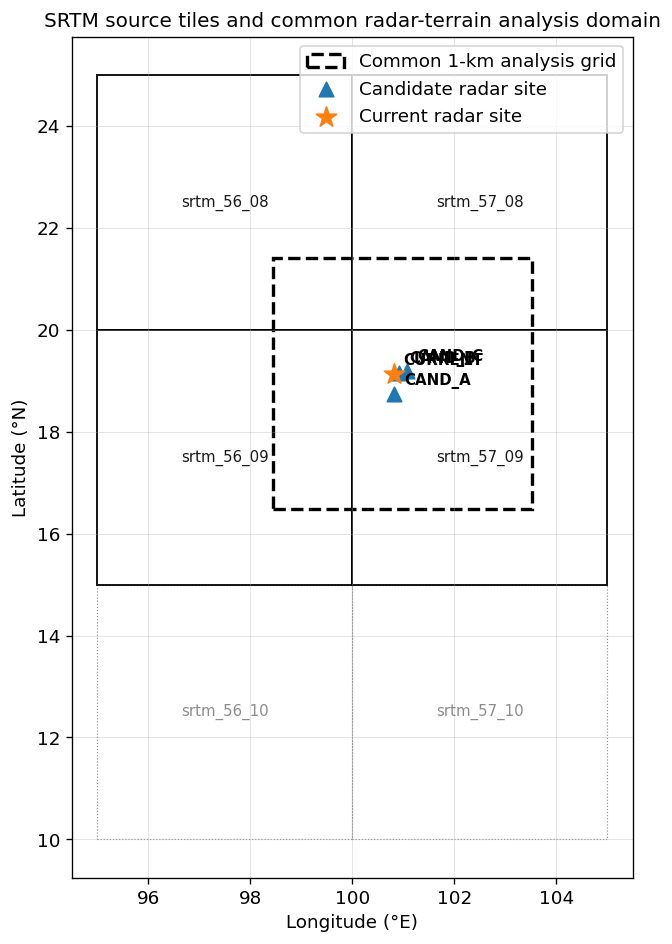

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig01_01_SRTM_Tiles_and_Radar_Analysis_Domain.png


In [12]:

# ============================================================
# STEP 12 — Figure 1: source tiles and radar analysis domain
# ============================================================

from matplotlib.patches import Rectangle

to_geo = Transformer.from_crs(
    TARGET_CRS,
    SOURCE_CRS,
    always_xy=True,
)

aoi_left_lon, aoi_bottom_lat = to_geo.transform(xmin, ymin)
aoi_right_lon, aoi_top_lat = to_geo.transform(xmax, ymax)

fig, ax = plt.subplots(figsize=(8.5, 8.0))

for _, row in tile_selection.iterrows():
    rect = Rectangle(
        (row["left"], row["bottom"]),
        row["right"] - row["left"],
        row["top"] - row["bottom"],
        fill=False,
        linewidth=1.2 if row["selected_for_aoi"] else 0.7,
        linestyle="-" if row["selected_for_aoi"] else ":",
        alpha=0.9 if row["selected_for_aoi"] else 0.45,
    )
    ax.add_patch(rect)

    ax.text(
        (row["left"] + row["right"]) / 2,
        (row["bottom"] + row["top"]) / 2,
        row["tile"],
        ha="center",
        va="center",
        fontsize=9,
        alpha=0.9 if row["selected_for_aoi"] else 0.45,
    )

aoi_rect = Rectangle(
    (aoi_left_lon, aoi_bottom_lat),
    aoi_right_lon - aoi_left_lon,
    aoi_top_lat - aoi_bottom_lat,
    fill=False,
    linewidth=2.0,
    linestyle="--",
    label="Common 1-km analysis grid",
)
ax.add_patch(aoi_rect)

existing = sites["status"].eq("Existing")
candidate = sites["status"].eq("Candidate")

ax.scatter(
    sites.loc[candidate, "longitude"],
    sites.loc[candidate, "latitude"],
    marker="^",
    s=75,
    label="Candidate radar site",
    zorder=5,
)

ax.scatter(
    sites.loc[existing, "longitude"],
    sites.loc[existing, "latitude"],
    marker="*",
    s=160,
    label="Current radar site",
    zorder=6,
)

for _, site in sites.iterrows():
    ax.annotate(
        site["site_id"],
        (site["longitude"], site["latitude"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        zorder=7,
    )

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")
ax.set_title(
    "SRTM source tiles and common radar-terrain analysis domain"
)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.legend(loc="best")
ax.set_aspect("equal", adjustable="box")

fig.tight_layout()

fig1_path = (
    FIGURES_DIR /
    "Fig01_01_SRTM_Tiles_and_Radar_Analysis_Domain.png"
)

fig.savefig(
    fig1_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig1_path)



# Part D — Reproject + Downsample + Mosaic

## 15. Memory-efficient processing

วิธีที่ **ไม่** ต้องการใน Colab คือ

```text
6 native SRTM tiles
        ↓
สร้าง native ~90-m mosaic ขนาดใหญ่มาก
        ↓
ค่อย resample เป็น 1 km
```

เพราะ array กลางอาจมีขนาดใหญ่โดยไม่จำเป็น

บทนี้ใช้แนวทาง

```text
Selected native tile 1 ─┐
Selected native tile 2 ─┼─► common 1-km UTM grid ─► mosaic
Selected native tile 3 ─┤
Selected native tile 4 ─┘
```

กล่าวคือ **แต่ละ source tile ถูก reproject/downsample เข้าสู่ destination grid โดยตรง**

กรณี cell บริเวณรอยต่อได้รับข้อมูลจากมากกว่าหนึ่ง tile จะเก็บค่าระดับที่สูงกว่า เพื่อคงแนวคิด conservative terrain representation


In [13]:

# ============================================================
# STEP 13 — Create the 1-km UTM MAX-elevation DEM
# ============================================================

mosaic = np.full(
    (height, width),
    DST_NODATA,
    dtype=np.float32,
)

processing_log = []

for i, row in selected.reset_index(drop=True).iterrows():
    tif_path = Path(row["tif_path"])
    hdr_path = tif_path.with_suffix(".hdr")

    (
        src_transform,
        src_crs,
        transform_source,
        _
    ) = effective_georeferencing(tif_path)

    print(
        f"[{i+1}/{len(selected)}] "
        f"Reprojecting {tif_path.name} ..."
    )

    with rasterio.open(tif_path) as src:
        src_nodata, nodata_source = detect_source_nodata(
            src,
            hdr_path,
        )

        temp = np.full(
            (height, width),
            DST_NODATA,
            dtype=np.float32,
        )

        reproject(
            source=rasterio.band(src, 1),
            destination=temp,
            src_transform=src_transform,
            src_crs=src_crs,
            src_nodata=src_nodata,
            dst_transform=dst_transform,
            dst_crs=TARGET_CRS,
            dst_nodata=DST_NODATA,
            resampling=DEM_RESAMPLING,
            init_dest_nodata=True,
            num_threads=2,
        )

    valid_new = temp != DST_NODATA
    valid_old = mosaic != DST_NODATA

    # Fill empty destination cells first.
    mosaic[valid_new & ~valid_old] = temp[
        valid_new & ~valid_old
    ]

    # Where tiles overlap, retain the higher terrain elevation.
    overlap = valid_new & valid_old
    mosaic[overlap] = np.maximum(
        mosaic[overlap],
        temp[overlap],
    )

    processing_log.append({
        "tile": tif_path.stem,
        "src_nodata": src_nodata,
        "nodata_source": nodata_source,
        "transform_source": transform_source,
        "valid_destination_cells": int(valid_new.sum()),
    })

print("\n✓ Reprojection/downsampling complete")

processing_log = pd.DataFrame(processing_log)
display(processing_log)


[1/4] Reprojecting srtm_56_08.tif ...
[2/4] Reprojecting srtm_56_09.tif ...
[3/4] Reprojecting srtm_57_08.tif ...
[4/4] Reprojecting srtm_57_09.tif ...

✓ Reprojection/downsampling complete


,tile,src_nodata,nodata_source,transform_source,valid_destination_cells
0,srtm_56_08,-32768.0,GeoTIFF,TFW,26836
1,srtm_56_09,-32768.0,GeoTIFF,TFW,64831
2,srtm_57_08,-32768.0,GeoTIFF,TFW,58585
3,srtm_57_09,-32768.0,GeoTIFF,TFW,142885



## 16. ตรวจค่าก่อนเขียน GeoTIFF

ก่อนบันทึก เราต้องแยก

- valid terrain cells
- NoData cells

และตรวจ physical plausibility แบบกว้าง ๆ

สำหรับ regional terrain dataset นี้เรากำหนด QC range


$$
-500 \le z \le 9000\ \text{m}
$$


เพื่อจับค่าที่ผิดปกติอย่างรุนแรง ไม่ใช่เพื่อบังคับว่าพื้นที่ศึกษาต้องมีระดับถึง 9000 m


In [14]:

# ============================================================
# STEP 14 — Pre-write DEM quality control
# ============================================================

valid = mosaic != DST_NODATA
valid_values = mosaic[valid]

if valid_values.size == 0:
    raise RuntimeError(
        "The output DEM contains no valid terrain cells."
    )

dem_min = float(valid_values.min())
dem_max = float(valid_values.max())
dem_mean = float(valid_values.mean())
valid_fraction = float(valid.mean())

print("1-km DEM pre-write QC")
print("---------------------")
print("Valid cells    :", f"{valid.sum():,}")
print("Total cells    :", f"{mosaic.size:,}")
print("Valid fraction :", f"{100*valid_fraction:.2f}%")
print("Minimum        :", f"{dem_min:.1f} m")
print("Maximum        :", f"{dem_max:.1f} m")
print("Mean           :", f"{dem_mean:.1f} m")

if dem_min < VALID_ELEV_MIN_M or dem_max > VALID_ELEV_MAX_M:
    print(
        "\n⚠ Terrain range exceeds the broad QC limits. "
        "Inspect before continuing."
    )
else:
    print("\n✓ Terrain values are within broad physical QC limits.")


1-km DEM pre-write QC
---------------------
Valid cells    : 292,008
Total cells    : 292,008
Valid fraction : 100.00%
Minimum        : 38.0 m
Maximum        : 2820.0 m
Mean           : 720.0 m

✓ Terrain values are within broad physical QC limits.


In [15]:

# ============================================================
# STEP 15 — Export compressed analysis GeoTIFF
# ============================================================

dem_out = (
    PROCESSED_DEM_DIR /
    "Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif"
)

profile = {
    "driver": "GTiff",
    "height": height,
    "width": width,
    "count": 1,
    "dtype": "float32",
    "crs": TARGET_CRS,
    "transform": dst_transform,
    "nodata": DST_NODATA,
    "compress": "DEFLATE",
    "predictor": 3,
    "tiled": True,
    "blockxsize": 256,
    "blockysize": 256,
    "BIGTIFF": "IF_SAFER",
}

with rasterio.open(
    dem_out,
    "w",
    **profile,
) as dst:
    dst.write(mosaic, 1)

    dst.set_band_description(
        1,
        "Terrain elevation (m)"
    )

    dst.update_tags(
        zenodo_doi="10.5281/zenodo.22687421",
        source_dem="SRTM approximately 3 arc-second source tiles",
        target_crs=TARGET_CRS.to_string(),
        target_resolution_m=str(TARGET_RES_M),
        resampling_method=DEM_RESAMPLING_NAME,
        radar_nbins=str(NBINS),
        radar_range_resolution_m=str(RANGE_RES_M),
        radar_max_range_km=str(MAX_RANGE_M / 1000.0),
        aoi_safety_buffer_km=str(AOI_BUFFER_M / 1000.0),
        processing_note=(
            "Maximum-elevation downsampling retained as a "
            "conservative terrain representation for radar "
            "beam-blockage screening."
        ),
    )

    # Overviews speed up GIS visualization only.
    dst.build_overviews(
        [2, 4, 8, 16],
        Resampling.average,
    )

    dst.update_tags(
        ns="rio_overview",
        resampling="average",
    )

print("✓ Analysis DEM saved")
print(dem_out)
print(
    "File size:",
    f"{dem_out.stat().st_size/1024**2:.2f} MB"
)


✓ Analysis DEM saved
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/01_processed_data/dem/Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif
File size: 0.69 MB



# Part E — Radar-site elevation: Native DEM vs 1-km MAX DEM

## 17. ทำไมต้องแยกค่าระดับของสถานี?

สมมติ radar อยู่บนพื้นที่ลาดเชิงเขา

ภายใน 1-km cell อาจมียอดเขาหรือ ridge ที่สูงกว่าตำแหน่ง radar มาก ดังนั้น


$$
z_{\mathrm{1km,max}}
$$


เป็นตัวแทน obstacle ภายใน cell มากกว่าระดับพื้นที่ ณ พิกัด radar

จึงต้อง sample


$$
z_{\mathrm{native}}
$$


จาก source DEM ใกล้พิกัดสถานีโดยตรง

สำหรับงานติดตั้งจริง ค่าที่ดีที่สุดยังคงเป็น


$$
H_{\mathrm{radar,MSL}}
=
H_{\mathrm{surveyed\ ground,MSL}}
+
H_{\mathrm{antenna,AGL}}
$$


Native DEM ในบทนี้ใช้สำหรับ QC/teaching และเป็น fallback เมื่อยังไม่มี surveyed elevation


In [16]:

# ============================================================
# STEP 16 — Sample native source DEM at each radar site
# ============================================================

def sample_native_dem(lon, lat, tile_table):
    """Sample the nearest native DEM cell at a lon/lat location."""

    for _, row in tile_table.iterrows():
        tif_path = Path(row["tif_path"])

        (
            src_transform,
            src_crs,
            _,
            _
        ) = effective_georeferencing(tif_path)

        to_source = Transformer.from_crs(
            SOURCE_CRS,
            src_crs,
            always_xy=True,
        )

        sx, sy = to_source.transform(
            lon,
            lat,
        )

        with rasterio.open(tif_path) as src:
            left, bottom, right, top = array_bounds(
                src.height,
                src.width,
                src_transform,
            )

            if (
                sx < left or sx > right or
                sy < bottom or sy > top
            ):
                continue

            r, c = rowcol(
                src_transform,
                sx,
                sy,
            )

            if (
                r < 0 or r >= src.height or
                c < 0 or c >= src.width
            ):
                continue

            value = src.read(
                1,
                window=Window(
                    int(c),
                    int(r),
                    1,
                    1,
                ),
            )[0, 0]

            nodata, _ = detect_source_nodata(
                src,
                tif_path.with_suffix(".hdr"),
            )

            if nodata is not None and value == nodata:
                return np.nan, tif_path.stem

            return float(value), tif_path.stem

    return np.nan, None


native_values = []
native_tiles = []

for _, site in sites.iterrows():
    value, source_tile = sample_native_dem(
        site["longitude"],
        site["latitude"],
        tile_meta,
    )
    native_values.append(value)
    native_tiles.append(source_tile)

sites["native_dem_m"] = native_values
sites["native_source_tile"] = native_tiles

with rasterio.open(dem_out) as ds:
    sample_xy = list(
        zip(
            sites["utm_x_m"],
            sites["utm_y_m"],
        )
    )

    sampled_1km = [
        float(v[0])
        for v in ds.sample(sample_xy)
    ]

sites["dem_1km_max_m"] = sampled_1km
sites["max_minus_native_m"] = (
    sites["dem_1km_max_m"] -
    sites["native_dem_m"]
)

display(
    sites[
        [
            "site_id",
            "site_name",
            "native_source_tile",
            "native_dem_m",
            "dem_1km_max_m",
            "max_minus_native_m",
        ]
    ].style.format({
        "native_dem_m": "{:.1f}",
        "dem_1km_max_m": "{:.1f}",
        "max_minus_native_m": "{:+.1f}",
    })
)

site_qc_csv = (
    METADATA_DIR /
    "01_site_elevation_native_vs_1km_MAX.csv"
)
sites.to_csv(
    site_qc_csv,
    index=False,
)

print("\nSaved:")
print(site_qc_csv)


,site_id,site_name,native_source_tile,native_dem_m,dem_1km_max_m,max_minus_native_m
0,CURRENT,"Tha Wang Pha, Nan",srtm_57_09,233.0,237.0,+4.0
1,CAND_A,"Tha Nao, Phu Phiang, Nan",srtm_57_09,235.0,241.0,+6.0
2,CAND_B,"Woranakhon, Pua, Nan",srtm_57_09,347.0,355.0,+8.0
3,CAND_C,"Phu Kha, Pua, Nan",srtm_57_09,1296.0,1368.0,+72.0



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/01_site_elevation_native_vs_1km_MAX.csv



## 18. ตีความตาราง Native vs 1-km MAX

ถ้า


$$
z_{\mathrm{1km,max}}
>
z_{\mathrm{native}}
$$


ไม่ควรแปลว่า DEM 1 km “ผิด”

แต่หมายความว่า cell 1 km นั้นมี terrain ที่สูงกว่าพิกัดเฉพาะของสถานี และ MAX resampling ตั้งใจรักษาค่าสูงนั้นไว้

นี่เป็นตัวอย่างที่ชัดเจนว่า **ค่าของ raster ขึ้นกับ spatial support**

- Native sample → จุด/พื้นที่ขนาดเล็กใกล้พิกัด radar
- 1-km MAX → ค่าสูงสุดที่เป็นตัวแทน cell ขนาดใหญ่กว่า

จึงไม่ควรใช้แทนกันโดยไม่พิจารณาวัตถุประสงค์



# Part F — Spatial Quality Control

## 19. ตรวจ DEM coverage ภายใน radar domain

การที่ GeoTIFF ถูกสร้างสำเร็จยังไม่พอ

ต้องตรวจว่าในวงกลมรัศมี 240 km ของแต่ละ site ไม่มี NoData จำนวนมาก เพราะ NoData ในพื้นที่ radar coverage จะทำให้ beam-blockage result ขาดหรือผิดพลาด

เราจะคำนวณ


$$
\text{Valid coverage}
=
\frac{N_{\mathrm{valid\ cells}}}
     {N_{\mathrm{cells\ within\ 240km}}}
\times100
$$



In [17]:

# ============================================================
# STEP 17 — Validate output raster and 240-km DEM coverage
# ============================================================

with rasterio.open(dem_out) as ds:
    dem = ds.read(1, masked=True)

    print("Output GeoTIFF")
    print("--------------")
    print("CRS        :", ds.crs)
    print("Resolution :", ds.res)
    print("Shape      :", ds.shape)
    print("Bounds     :", ds.bounds)
    print("NoData     :", ds.nodata)
    print("Valid min  :", float(dem.min()))
    print("Valid max  :", float(dem.max()))
    print("Valid mean :", float(dem.mean()))

    # Cell-centre coordinates
    x_centres = (
        ds.transform.c +
        (np.arange(ds.width) + 0.5) * ds.transform.a
    )

    y_centres = (
        ds.transform.f +
        (np.arange(ds.height) + 0.5) * ds.transform.e
    )

    xx, yy = np.meshgrid(
        x_centres,
        y_centres,
    )

    raster_valid = ~np.ma.getmaskarray(dem)

coverage_rows = []

for _, site in sites.iterrows():
    distance = np.sqrt(
        (xx - site["utm_x_m"])**2 +
        (yy - site["utm_y_m"])**2
    )

    inside = distance <= MAX_RANGE_M
    n_inside = int(inside.sum())
    n_valid = int((inside & raster_valid).sum())

    pct = (
        100.0 * n_valid / n_inside
        if n_inside > 0
        else np.nan
    )

    coverage_rows.append({
        "site_id": site["site_id"],
        "cells_within_240km": n_inside,
        "valid_cells": n_valid,
        "valid_coverage_pct": pct,
    })

coverage_qc = pd.DataFrame(
    coverage_rows
)

display(
    coverage_qc.style.format({
        "valid_coverage_pct": "{:.3f}"
    })
)

coverage_csv = (
    METADATA_DIR /
    "01_dem_coverage_within_240km.csv"
)

coverage_qc.to_csv(
    coverage_csv,
    index=False,
)

print("\nSaved:")
print(coverage_csv)


Output GeoTIFF
--------------
CRS        : EPSG:32647
Resolution : (1000.0, 1000.0)
Shape      : (552, 529)
Bounds     : BoundingBox(left=440000.0, bottom=1822000.0, right=969000.0, top=2374000.0)
NoData     : -9999.0
Valid min  : 38.0
Valid max  : 2820.0
Valid mean : 720.0343552231445


,site_id,cells_within_240km,valid_cells,valid_coverage_pct
0,CURRENT,180957,180957,100.000
1,CAND_A,180942,180942,100.000
2,CAND_B,180949,180949,100.000
3,CAND_C,180940,180940,100.000



Saved:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/02_metadata/01_dem_coverage_within_240km.csv



## 20. Figure 2 — Final 1-km terrain analysis DEM

นี่คือแผนที่หลักของ Notebook

ต้องแสดงให้เห็นพร้อมกันว่า

- DEM อยู่ใน UTM Zone 47N
- grid มี resolution 1 km
- เรดาร์ทั้ง 4 จุดอยู่ในตำแหน่งสัมพันธ์กับภูมิประเทศอย่างไร
- radar range 240 km อยู่ภายใน valid DEM coverage
- regional mountain barriers อยู่ในทิศใดเมื่อเทียบกับแต่ละ site

ตามมาตรฐานของชุดแบบเรียน DEM ใช้ **`terrain`** เสมอ


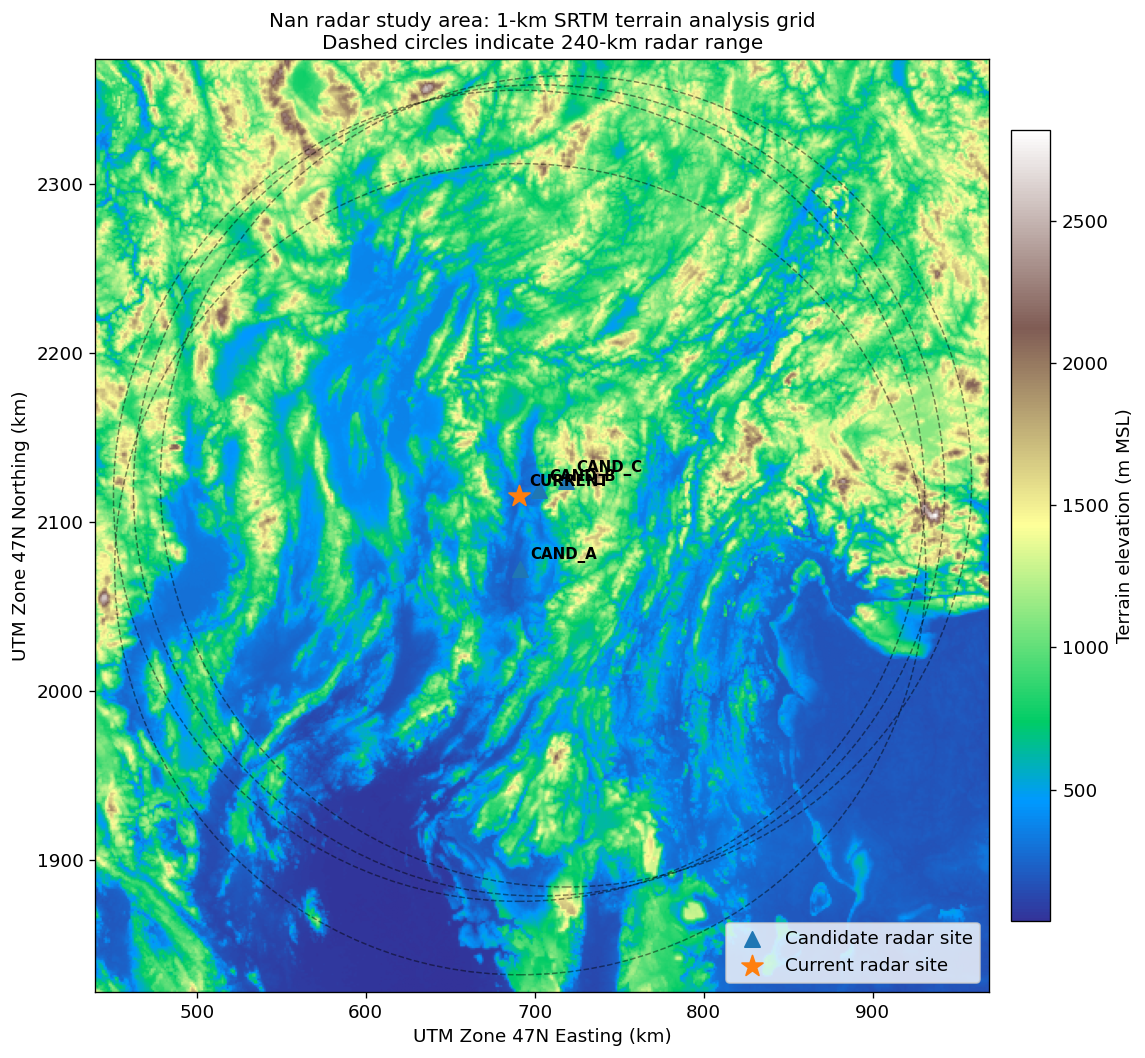

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig01_02_Nan_Radar_1km_SRTM_Terrain_240km_Ranges.png


In [18]:

# ============================================================
# STEP 18 — Figure 2: final 1-km UTM DEM and radar ranges
# ============================================================

from matplotlib.patches import Circle

with rasterio.open(dem_out) as ds:
    dem_plot = ds.read(1, masked=True)

    extent_km = [
        ds.bounds.left / 1000.0,
        ds.bounds.right / 1000.0,
        ds.bounds.bottom / 1000.0,
        ds.bounds.top / 1000.0,
    ]

fig, ax = plt.subplots(
    figsize=(10.0, 9.0)
)

im = ax.imshow(
    dem_plot,
    cmap=DEM_CMAP,
    extent=extent_km,
    origin="upper",
)

# 240-km range ring for each site
for _, site in sites.iterrows():
    ring = Circle(
        (
            site["utm_x_m"] / 1000.0,
            site["utm_y_m"] / 1000.0,
        ),
        MAX_RANGE_M / 1000.0,
        fill=False,
        linestyle="--",
        linewidth=0.9,
        alpha=0.45,
    )
    ax.add_patch(ring)

existing = sites["status"].eq("Existing")
candidate = sites["status"].eq("Candidate")

ax.scatter(
    sites.loc[candidate, "utm_x_m"] / 1000.0,
    sites.loc[candidate, "utm_y_m"] / 1000.0,
    marker="^",
    s=85,
    label="Candidate radar site",
    zorder=5,
)

ax.scatter(
    sites.loc[existing, "utm_x_m"] / 1000.0,
    sites.loc[existing, "utm_y_m"] / 1000.0,
    marker="*",
    s=175,
    label="Current radar site",
    zorder=6,
)

for _, site in sites.iterrows():
    ax.annotate(
        site["site_id"],
        (
            site["utm_x_m"] / 1000.0,
            site["utm_y_m"] / 1000.0,
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        zorder=7,
    )

cbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.82,
    pad=0.02,
)
cbar.set_label(
    "Terrain elevation (m MSL)"
)

ax.set_xlabel(
    "UTM Zone 47N Easting (km)"
)
ax.set_ylabel(
    "UTM Zone 47N Northing (km)"
)
ax.set_title(
    "Nan radar study area: 1-km SRTM terrain analysis grid\n"
    "Dashed circles indicate 240-km radar range"
)

ax.set_aspect(
    "equal",
    adjustable="box",
)
ax.legend(loc="best")

fig.tight_layout()

fig2_path = (
    FIGURES_DIR /
    "Fig01_02_Nan_Radar_1km_SRTM_Terrain_240km_Ranges.png"
)

fig.savefig(
    fig2_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig2_path)



## 21. Figure 3 — Local terrain setting ของทั้ง 4 sites

Figure 2 เหมาะกับ regional context แต่ตำแหน่ง candidate sites อยู่ใกล้กันมากเมื่อเทียบกับ domain 240 km

Figure นี้จึง zoom เข้าเฉพาะ local terrain เพื่อถามคำถามทางภูมิศาสตร์ว่า

> แต่ละตำแหน่งอยู่บน valley, slope, ridge หรือ mountain setting แบบใด?

การเข้าใจ local terrain มีความสำคัญก่อนการตีความ beam blockage และก่อนการกำหนด antenna height


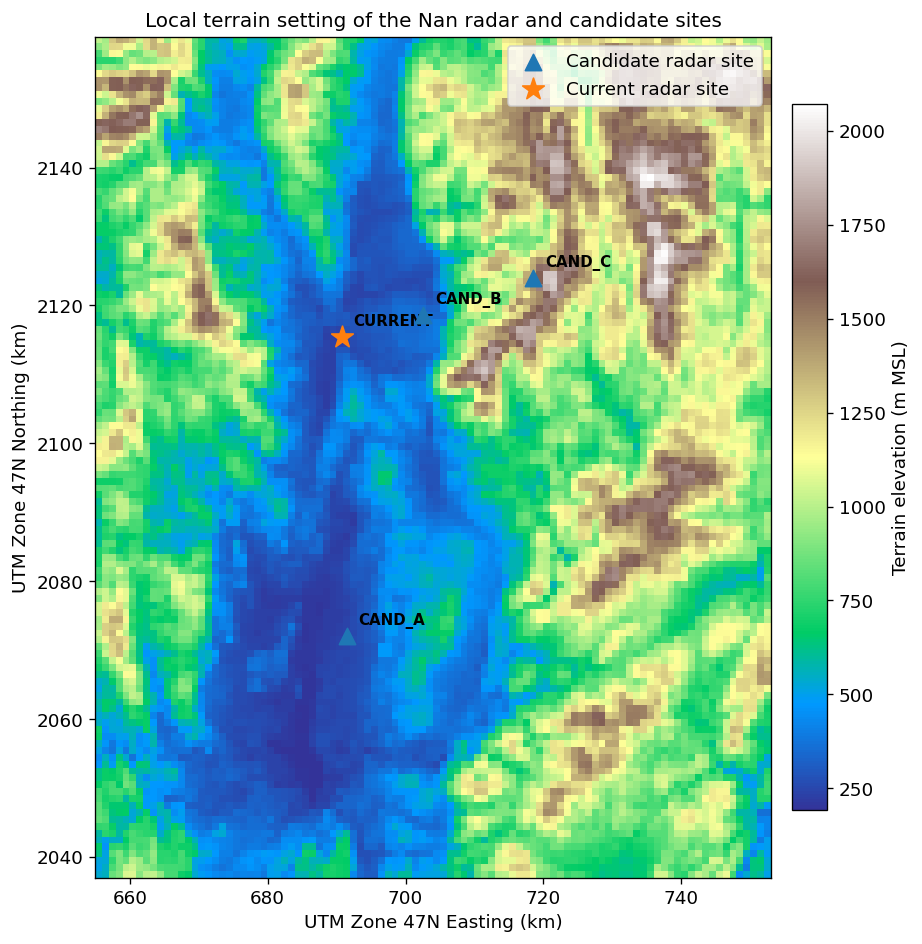

Saved: /content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/04_figures/Fig01_03_Nan_Radar_Candidate_Sites_Local_Terrain.png


In [19]:

# ============================================================
# STEP 19 — Figure 3: local terrain around candidate sites
# ============================================================

local_buffer_m = 35_000.0

local_xmin = sites["utm_x_m"].min() - local_buffer_m
local_xmax = sites["utm_x_m"].max() + local_buffer_m
local_ymin = sites["utm_y_m"].min() - local_buffer_m
local_ymax = sites["utm_y_m"].max() + local_buffer_m

with rasterio.open(dem_out) as ds:
    local_window = rasterio.windows.from_bounds(
        local_xmin,
        local_ymin,
        local_xmax,
        local_ymax,
        transform=ds.transform,
    ).round_offsets().round_lengths()

    local_dem = ds.read(
        1,
        window=local_window,
        masked=True,
    )

    local_transform = ds.window_transform(
        local_window
    )

    local_bounds = rasterio.windows.bounds(
        local_window,
        ds.transform,
    )

local_extent_km = [
    local_bounds[0] / 1000.0,
    local_bounds[2] / 1000.0,
    local_bounds[1] / 1000.0,
    local_bounds[3] / 1000.0,
]

fig, ax = plt.subplots(
    figsize=(9.0, 8.0)
)

im = ax.imshow(
    local_dem,
    cmap=DEM_CMAP,
    extent=local_extent_km,
    origin="upper",
)

ax.scatter(
    sites.loc[candidate, "utm_x_m"] / 1000.0,
    sites.loc[candidate, "utm_y_m"] / 1000.0,
    marker="^",
    s=95,
    label="Candidate radar site",
    zorder=5,
)

ax.scatter(
    sites.loc[existing, "utm_x_m"] / 1000.0,
    sites.loc[existing, "utm_y_m"] / 1000.0,
    marker="*",
    s=185,
    label="Current radar site",
    zorder=6,
)

for _, site in sites.iterrows():
    ax.annotate(
        site["site_id"],
        (
            site["utm_x_m"] / 1000.0,
            site["utm_y_m"] / 1000.0,
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

cbar = fig.colorbar(
    im,
    ax=ax,
    shrink=0.84,
    pad=0.02,
)

cbar.set_label(
    "Terrain elevation (m MSL)"
)

ax.set_title(
    "Local terrain setting of the Nan radar and candidate sites"
)
ax.set_xlabel(
    "UTM Zone 47N Easting (km)"
)
ax.set_ylabel(
    "UTM Zone 47N Northing (km)"
)
ax.set_aspect(
    "equal",
    adjustable="box",
)
ax.legend(loc="best")

fig.tight_layout()

fig3_path = (
    FIGURES_DIR /
    "Fig01_03_Nan_Radar_Candidate_Sites_Local_Terrain.png"
)

fig.savefig(
    fig3_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", fig3_path)



# Part G — สรุปและการตีความ

## 22. สิ่งที่ต้องเข้าใจก่อนเข้าสู่ radar beam geometry

Notebook นี้ได้เปลี่ยน source terrain representation จาก


$$
\text{SRTM 3 arc-sec geographic DEM}
$$


ไปเป็น


$$
\text{1-km UTM Zone 47N MAX-elevation DEM}
$$


แต่ต้องจำว่าเราได้เปลี่ยน **ทั้ง coordinate representation และ spatial support**

### สิ่งที่เปลี่ยน

- CRS: EPSG:4326 → EPSG:32647
- unit แนวราบ: degree → metre
- grid spacing: ~3 arc-sec → exactly 1,000 m
- terrain representation: native elevation → maximum elevation within resampling support

### สิ่งที่ไม่ได้เปลี่ยน

DEM ยังคงเป็นตัวแทน **terrain elevation** และไม่ใช่ radar beam height

ในบทถัดไปเราจึงจะเพิ่ม physics ของลำบีมเข้าไป:


$$
\text{Terrain}
+
\text{Radar elevation angle}
+
\text{Earth curvature}
+
\text{Atmospheric refraction}
$$


ก่อนคำนวณ PBB/CBB ในบทหลังจากนั้น



## 23. แบบฝึกคิด (Conceptual Exercises)

**ระดับ CORE**

1. เพราะเหตุใด pixel size `0.00083333°` จึงไม่ใช่ 90 m แบบ exact?
2. EPSG:32647 ช่วยให้นิยาม 240-km radar domain ง่ายขึ้นอย่างไร?
3. ถ้าใช้ `average` แทน `max` สันเขาแคบอาจเปลี่ยนอย่างไร?

**ระดับ ADVANCED**

4. เหตุใด MAX resampling อาจสร้าง positive terrain bias ภายใน 1-km cell?
5. ถ้าระยะ gate ของ radar คือ 500 m แต่ DEM คือ 1 km จะมีผลด้าน scale mismatch อย่างไร?
6. การใช้ rectangular common grid แทน union of four circles มีข้อดีและข้อเสียอะไร?

**RESEARCH EXTENSION**

7. ออกแบบ sensitivity experiment เปรียบเทียบ 100, 250, 500 และ 1000 m DEM
8. เสนอ metric ที่ใช้วัดว่าผล CBB ไวต่อ DEM resolution เพียงใด
9. หากงานวิจัยเปลี่ยนจาก site screening เป็น engineering siting จริง ควรเพิ่มข้อมูลภูมิประเทศหรือ survey ประเภทใด?


In [20]:

# ============================================================
# STEP 20 — Save processing metadata and final readiness gate
# ============================================================

processing_metadata = {
    "source_dataset_doi": provenance.get(
        "zenodo_doi",
        "10.5281/zenodo.22687421",
    ),
    "source_tile_count": int(len(source_tifs)),
    "selected_tile_count": int(len(selected)),
    "source_crs": SOURCE_CRS.to_string(),
    "target_crs": TARGET_CRS.to_string(),
    "target_resolution_m": TARGET_RES_M,
    "resampling_method": DEM_RESAMPLING_NAME,
    "radar_nbins": NBINS,
    "radar_range_resolution_m": RANGE_RES_M,
    "radar_max_range_km": MAX_RANGE_M / 1000.0,
    "aoi_buffer_km": AOI_BUFFER_M / 1000.0,
    "output_dem": str(dem_out),
    "output_bounds_utm": [xmin, ymin, xmax, ymax],
    "output_shape": [height, width],
    "valid_dem_min_m": dem_min,
    "valid_dem_max_m": dem_max,
    "valid_dem_mean_m": dem_mean,
}

processing_json = (
    METADATA_DIR /
    "01_dem_preprocessing_metadata.json"
)

with open(
    processing_json,
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        processing_metadata,
        f,
        indent=2,
        ensure_ascii=False,
    )

# Final checks
with rasterio.open(dem_out) as ds:
    crs_ok = ds.crs == TARGET_CRS
    resolution_ok = (
        abs(ds.res[0] - TARGET_RES_M) < 1e-6 and
        abs(ds.res[1] - TARGET_RES_M) < 1e-6
    )

coverage_ok = bool(
    (coverage_qc["valid_coverage_pct"] >= 99.0).all()
)

terrain_ok = (
    dem_min >= VALID_ELEV_MIN_M and
    dem_max <= VALID_ELEV_MAX_M
)

site_native_ok = bool(
    np.isfinite(
        sites["native_dem_m"].to_numpy(dtype=float)
    ).all()
)

final_checks = {
    "Output GeoTIFF exists": dem_out.exists(),
    "CRS is EPSG:32647": crs_ok,
    "Resolution is exactly 1,000 m": resolution_ok,
    "≥99% valid DEM coverage in every 240-km domain": coverage_ok,
    "Terrain values pass broad physical QC": terrain_ok,
    "Native DEM elevation found for all radar sites": site_native_ok,
    "Processing metadata JSON saved": processing_json.exists(),
}

print("=" * 76)
print("NOTEBOOK 01 — FINAL READINESS CHECK")
print("=" * 76)

all_ok = True

for label, status in final_checks.items():
    print(("✓" if status else "✗"), label)
    all_ok = all_ok and status

print("=" * 76)

print("\nPrimary DEM for the next notebook:")
print(dem_out)

if all_ok:
    print(
        "\n✓ TERRAIN DATA READY — proceed to Notebook 02: "
        "Radar Beam Geometry."
    )
else:
    print(
        "\n⚠ One or more QC checks require inspection before "
        "proceeding to radar beam geometry."
    )


NOTEBOOK 01 — FINAL READINESS CHECK
✓ Output GeoTIFF exists
✓ CRS is EPSG:32647
✓ Resolution is exactly 1,000 m
✓ ≥99% valid DEM coverage in every 240-km domain
✓ Terrain values pass broad physical QC
✓ Native DEM elevation found for all radar sites
✓ Processing metadata JSON saved

Primary DEM for the next notebook:
/content/drive/MyDrive/Teaching_Radar_Terrain_BeamBlockage/01_processed_data/dem/Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif

✓ TERRAIN DATA READY — proceed to Notebook 02: Radar Beam Geometry.



# 24. สรุปบทเรียน

จาก Notebook นี้ เราเรียนรู้ว่า DEM preprocessing สำหรับ radar meteorology ไม่ใช่เพียงการเปลี่ยนขนาด raster แต่เป็นการตัดสินใจเชิงภูมิสารสนเทศที่ส่งผลต่อคำตอบทางฟิสิกส์ในขั้นต่อไป


$$
\boxed{
\text{Source DEM}
\rightarrow
\text{Georeferencing QC}
\rightarrow
\text{Metric CRS}
\rightarrow
\text{Radar domain}
\rightarrow
\text{MAX resampling}
\rightarrow
\text{1-km terrain grid}
}
$$


Output หลัก:

```text
01_processed_data/dem/
└── Nan_Radar_SRTM_DEM_1km_UTM47N_MAX.tif
```

Output สำหรับ reproducibility/QC:

```text
02_metadata/
├── 01_source_dem_georeferencing_QC.csv
├── 01_radar_sites_utm.csv
├── 01_dem_tile_selection_for_240km_AOI.csv
├── 01_site_elevation_native_vs_1km_MAX.csv
├── 01_dem_coverage_within_240km.csv
└── 01_dem_preprocessing_metadata.json
```

Figures:

```text
04_figures/
├── Fig01_01_SRTM_Tiles_and_Radar_Analysis_Domain.png
├── Fig01_02_Nan_Radar_1km_SRTM_Terrain_240km_Ranges.png
└── Fig01_03_Nan_Radar_Candidate_Sites_Local_Terrain.png
```

---

## Next: Notebook 02 — Radar Beam Geometry

บทต่อไปจะยัง **ไม่คำนวณ PBB/CBB**

เราจะเริ่มจากฟิสิกส์และ geometry ของลำบีม:


$$
r,\ \theta,\ kR_e,\ h_0
\rightarrow
H_{\mathrm{beam}}
$$


และศึกษาว่า elevation angles


$$
0.5^\circ,\ 1.0^\circ,\ 1.5^\circ,\ 2.0^\circ
$$


มีระดับความสูงเหนือพื้นโลกเปลี่ยนไปตามระยะทางอย่างไร ก่อนนำ beam ไปตัดกับ DEM
